# **08장. 인공 신경망으로 구현하는 분류 모델**

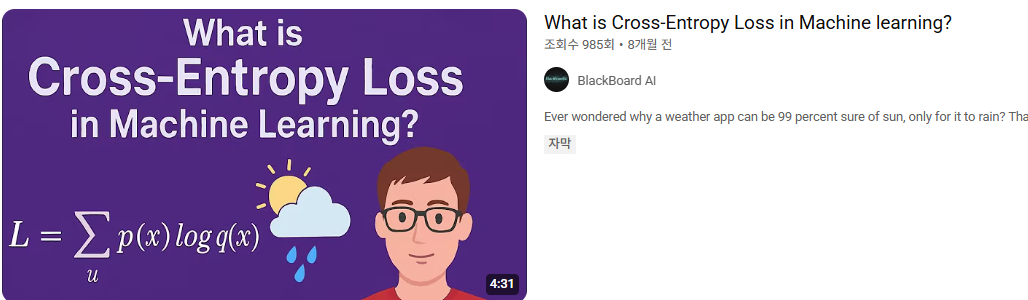

https://www.youtube.com/watch?v=8mzZsAAclbA

이 동영상은 분류 모델의 손실 함수로 사용되는 **크로스_엔트로피**의 계산방법을 쉽게 설명합니다.

* 모델이 예측한 클래스별 확률과 실제 타깃의 원핫 인코딩 벡터(하나만 1)을 비교하여, 그 차이를 계산하는 방법입니다.   


---




In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
import pandas as pd; import numpy as np; import matplotlib.pyplot as plt
from sklearn.metrics import r2_score; import seaborn as sns
import tensorflow as tf; from tensorflow import keras
from keras.models import Model, Sequential
from keras.layers import Input, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score; import random
import warnings; warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 74.2 MB/s eta 0:00:00


[실습 08-01]

In [ ]:
df=pd.read_csv("구종분류.csv", encoding="cp949")
df

,velocity,spin_rate,horizontal_break,vertical_break,release_angle,구종
0,95.692896,2347.535622,1.844323,7.296631,56.056166,직구
1,79.302915,2511.400809,11.327105,2.881931,62.432425,슬라이더
2,75.064949,2467.935772,10.109868,17.561928,63.430116,커브
3,96.476933,2120.747926,2.384065,9.328431,54.851609,직구
4,79.207489,2648.806352,13.346443,3.489187,58.998542,슬라이더
...,...,...,...,...,...,...
795,96.645090,2414.394409,3.502357,7.975791,54.895945,직구
796,82.911808,1631.265565,6.486472,7.977816,63.671322,체인지업
797,85.509866,1712.167692,7.176353,9.462761,58.958574,커브
798,83.711111,1706.207442,6.745373,10.905233,57.609819,커브


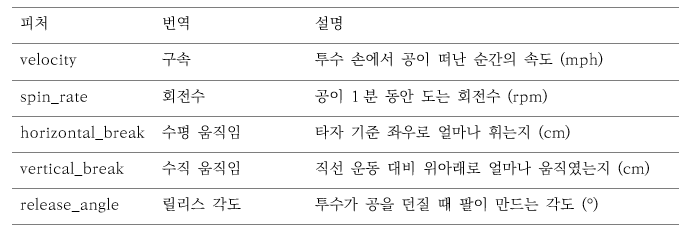

[실습 08-02]

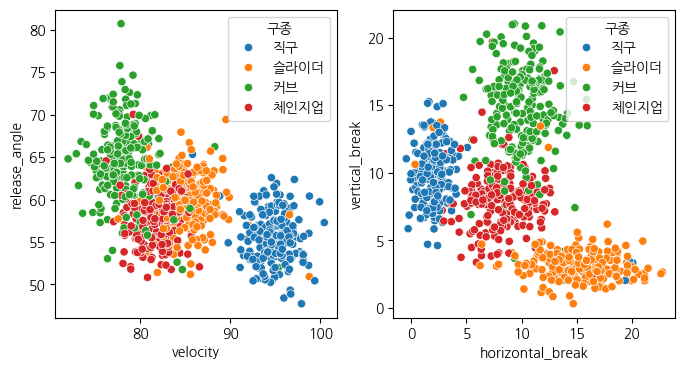

In [ ]:
plt.figure(figsize=(8, 4))

plt.subplot(1,2,1)
sns.scatterplot(x=df["velocity"], y=df["release_angle"], hue=df["구종"])

plt.subplot(1,2,2)
sns.scatterplot(x=df["horizontal_break"], y=df["vertical_break"], hue=df["구종"])

plt.show()

[실습 08-03]

In [ ]:
X=df.drop("구종", axis=1)
y=df["구종"]

# 타겟을 원핫 인코딩
y_oh=pd.get_dummies(y).astype(int)
print(y_oh.head(5)); print()

X=np.array(X)
y_oh=np.array(y_oh)

num_class=y_oh.shape[1]
print("타깃 클래스의 수=", num_class)

   슬라이더  직구  체인지업  커브
0     0   1     0   0
1     1   0     0   0
2     0   0     0   1
3     0   1     0   0
4     1   0     0   0

타깃 클래스의 수= 4


[실습 08-04], [실습 08-05]

In [ ]:
SEED=42; np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(X, y_oh, test_size=0.3, random_state=SEED)

MLB=Sequential([
    Input(shape=x_train[0].shape),
    Dense(16, activation='relu'),
    Dense(8,  activation='relu'),
    Dense(4,  activation='softmax') ])

MLB.summary()

MLB.compile(optimizer="adam", loss="categorical_crossentropy",
             metrics=["accuracy"])   # metrics는 추가로 계산할 통계 설정

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268 (1.05 KB)

 Trainable params: 268 (1.05 KB)

 Non-trainable params: 0 (0.00 B)

▶	클래스가 2개인 이진 분류 문제에서는 출력층의 확률 계산을 위해 시그모이드(sigmoid) 활성화 함수를 사용할 수 있습니다.

▶	시그모이드는 소프트맥스의 특수한 경우입니다.

▶ 이 책에서는 클래스의 수에 관계없이 동일한 구조로 설명하기 위해 일관되게 소프트맥스 함수를 사용하겠습니다.

[실습 08-06]

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop=EarlyStopping(
    monitor='val_loss',             # 검증 손실을 모니터링
    patience=5,                     # 5번 연속 개선되지 않으면 멈춤
    restore_best_weights=True)      # 가장 좋은 모델로 파라미터 복원

hist=MLB.fit(x_train, y_train, epochs=300, validation_data=(x_test, y_test), callbacks=[early_stop])

Epoch 1/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.2429 - loss: 187.0667 - val_accuracy: 0.2667 - val_loss: 105.2572
Epoch 2/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2464 - loss: 91.2353 - val_accuracy: 0.3333 - val_loss: 39.2301
Epoch 3/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2661 - loss: 25.7643 - val_accuracy: 0.1917 - val_loss: 8.1692
Epoch 4/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2571 - loss: 6.0694 - val_accuracy: 0.3417 - val_loss: 3.1445
Epoch 5/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3000 - loss: 2.5614 - val_accuracy: 0.2333 - val_loss: 2.0995
Epoch 6/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3000 - loss: 1.9320 - val_accuracy: 0.2375 - val_loss: 1.7186
Epoch 7/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3089 - loss: 1.7241 - val_accuracy: 0.3542 - val_loss: 1.6492
Epoch 8/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3232 - loss: 1.6406 - val_accuracy: 

[실습 08-07]

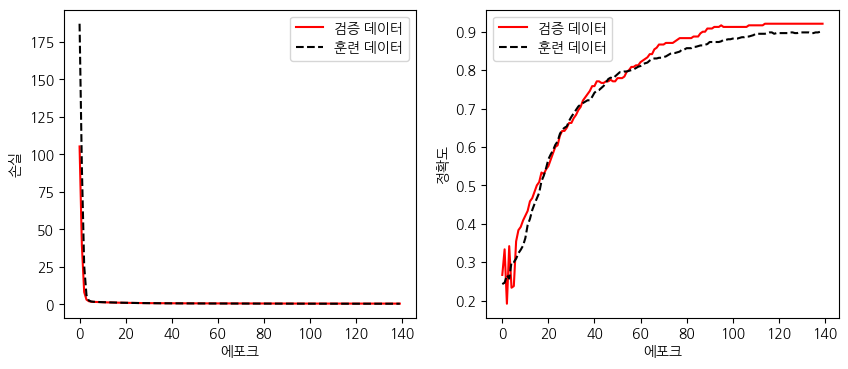

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1,2,1)
plt.plot(hist.history['val_loss'], 'r-', label='검증 데이터')
plt.plot(hist.history['loss'], 'k--', label='훈련 데이터')
plt.xlabel('에포크'); plt.ylabel('손실')
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist.history['val_accuracy'], 'r-', label='검증 데이터')
plt.plot(hist.history['accuracy'],'k--',  label='훈련 데이터')
plt.xlabel('에포크'); plt.ylabel('정확도')
plt.legend()

plt.show()

[실습 08-08]

In [ ]:
y_prob=MLB.predict(x_test)
print(y_prob[:5])   # 첫 5행 출력

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[[2.8789787e-02 2.2256009e-03 1.4812596e-01 8.2085872e-01]
 [9.5828509e-01 1.0198890e-03 5.4392866e-03 3.5255741e-02]
 [7.2515579e-03 1.0484862e-04 8.5475529e-03 9.8409605e-01]
 [2.5471650e-02 9.1839027e-01 4.2560764e-02 1.3577317e-02]
 [9.8577565e-01 4.9232563e-05 7.6777441e-04 1.3407391e-02]]


[실습 08-09]

In [ ]:
class_labels=["슬라이더", "직구", "체인지업", "커브"]

y_pred=np.argmax(y_prob, axis=1)
print(y_pred[:5])
y_pred_labels=[ class_labels[i] for i in y_pred]
y_pred_labels[:5]


[3 0 3 1 0]


['커브', '슬라이더', '커브', '직구', '슬라이더']

[실습 08-10]

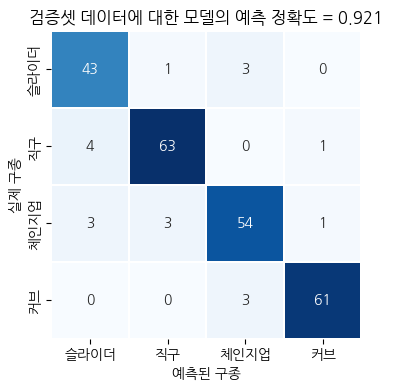

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_idx=np.argmax(y_test,axis=1) # y_test(원핫)도 인덱스로 변환해야 함

acc=accuracy_score(y_idx, y_pred)  # 분류정확도 계산

cm=confusion_matrix(y_idx, y_pred) # 혼동행렬 생성

plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True,linewidths=0.1, cmap='Blues',cbar=None,
            xticklabels=class_labels, yticklabels=class_labels)
plt.ylabel('실제 구종'); plt.xlabel('예측된 구종')
plt.title(f'검증셋 데이터에 대한 모델의 예측 정확도 = {acc:.3f}')
plt.show()

**새로운 데이터에 대한 예측**

[실습 08-11]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step


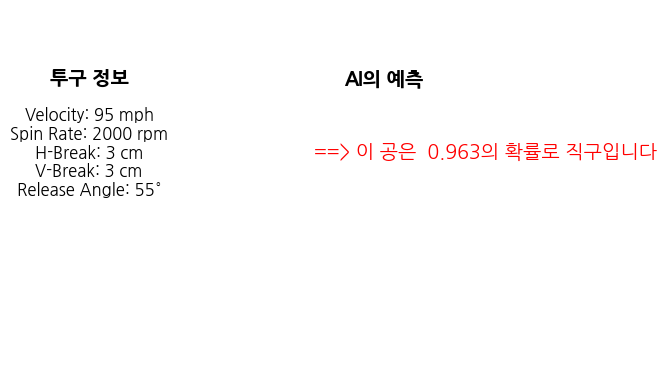

In [ ]:
new_pitch={                # 딕셔너리 자료 생성
    "velocity": 95,
    "spin_rate": 2000,
    "horizontal_break": 3,
    "vertical_break": 3,
    "release_angle": 55 }

new_df=pd.DataFrame([new_pitch])  # 데이터프레임으로 변환
prob=MLB.predict(new_df)          # 예측 확률 계산
pred=np.argmax(prob, axis=1)      # 예측된 클래스 인덱스

# 결과 시각화
plt.text(0.1, 0.8, "투구 정보", ha="center", fontsize=14, weight="bold")
plt.text(0.1, 0.5,
        f"Velocity: {new_pitch['velocity']} mph\n"
        f"Spin Rate: {new_pitch['spin_rate']} rpm\n"
        f"H-Break: {new_pitch['horizontal_break']} cm\n"
        f"V-Break: {new_pitch['vertical_break']} cm\n"
        f"Release Angle: {new_pitch['release_angle']}°",
        ha="center", fontsize=12)
plt.text(0.7, 0.8, "AI의 예측 ", ha="center", fontsize=14, weight="bold")
plt.text(0.9, 0.6, f"==> 이 공은  {np.max(prob, axis=1).item():.3f}의 확률로 {class_labels[pred.item()]}입니다",
        ha="center", fontsize=14, color="red")

plt.xlim(0, 1); plt.ylim(0, 1); plt.axis("off")
plt.show()


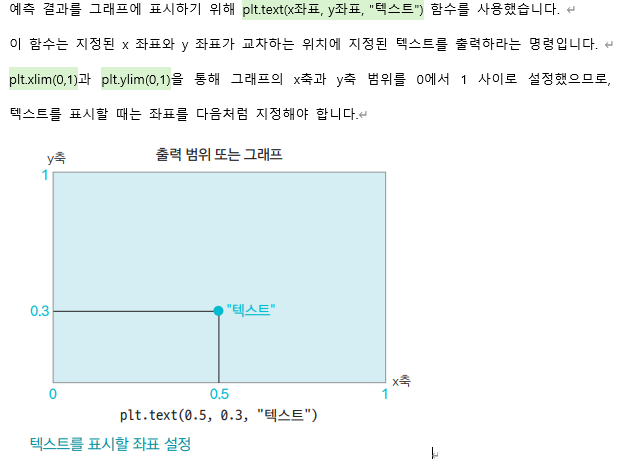

[실습 08-12]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


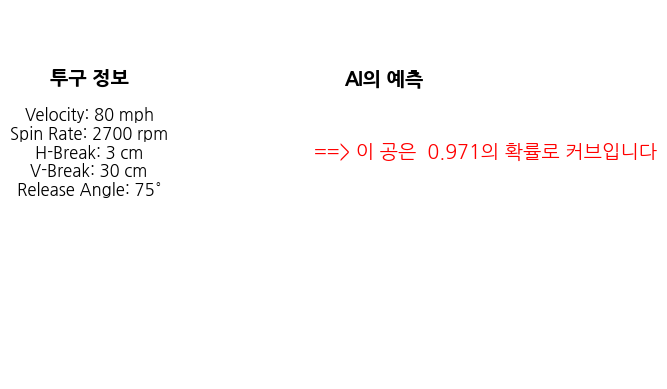

In [ ]:
new_pitch={                # 딕셔너리 자료
    "velocity": 80,
    "spin_rate": 2700,
    "horizontal_break": 3,
    "vertical_break": 30,
    "release_angle": 75 }
new_df=pd.DataFrame([new_pitch])  # 데이터프레임 변환
prob=MLB.predict(new_df)          # 예측 확률 계산
pred=np.argmax(prob, axis=1)      # 예측된 클래스 인덱스

# 결과 시각화
plt.text(0.1, 0.8, "투구 정보", ha="center", fontsize=14, weight="bold")
plt.text(0.1, 0.5,
        f"Velocity: {new_pitch['velocity']} mph\n"
        f"Spin Rate: {new_pitch['spin_rate']} rpm\n"
        f"H-Break: {new_pitch['horizontal_break']} cm\n"
        f"V-Break: {new_pitch['vertical_break']} cm\n"
        f"Release Angle: {new_pitch['release_angle']}°",
        ha="center", fontsize=12)
plt.text(0.7, 0.8, "AI의 예측 ", ha="center", fontsize=14, weight="bold")
plt.text(0.9, 0.6, f"==> 이 공은  {np.max(prob, axis=1).item():.3f}의 확률로 {class_labels[pred.item()]}입니다",
        ha="center", fontsize=14, color="red")

plt.xlim(0, 1); plt.ylim(0, 1); plt.axis("off")
plt.show()


## **[보충]  비지도 학습 알아보기**
비지도학습은 타깃이 없는 데이터에서 어떤 패턴을 추출하는 방법입니다.

대표적인 비지도학습 알고리즘인 **K-Means** 모델을 살펴 봅시다.
- 이 모델은 입력 변수(구종 특성)만 활용하여, 샘플을 K개의 그룹으로 나눠주는 분류 기법입니다.



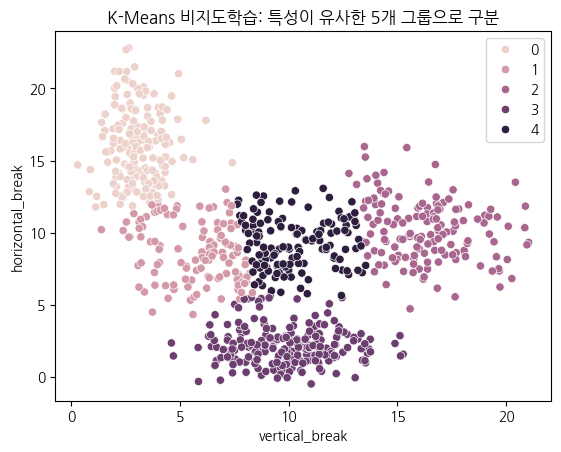

In [ ]:
# 비지도 학습 모델 클래스 불러오기
from sklearn.cluster import KMeans

# 입력(특성) 변수 지정
z=df[['vertical_break', 'horizontal_break']]
#z=df[['vertical_break', 'horizontal_break', 'spin_rate']]

# 그룹 수 설정
K=5

# 군집화 모델 설정
c_model= KMeans(n_clusters=K, random_state=42)

# 군집화 모델 학습
c_model.fit(z)

# 군집화 결과(그룹 인덱스)
labels = c_model.labels_

# 시각화
sns.scatterplot(x=q["vertical_break"], y=q["horizontal_break"], hue=labels, color='bright')
plt.title(f"K-Means 비지도학습: 특성이 유사한 {K}개 그룹으로 구분")
plt.show()


- 이 코드에서 입력 변수와 K를 바꾸어 실행해보세요
- 각 입력 벡터간의 **좌표간 거리**를 구하여, 가까운 좌표를 같은 그룹으로 묶어주는 연산이 사용됩니다.  
- 고객의 특성을 바탕으로 다수의 소집단(**세그먼트**)으로 나누어 관리하는 목적으로 자주 사용합니다.
- 타깃이 없으므로 정확도는 계산되지 않습니다.


---



## **[선택] 인공신경망의 행렬과 텐서 연산을 직접 코딩**
* 텐서의 고속 연산을 체험하려면 런타임이 CPU가 아닌 GPU 또는 TPU로 설정되어야 합니다.

Epoch 1: Train_loss 516.2914, Test_loss 12.9616
Epoch 2: Train_loss 330.5936, Test_loss 12.9616
Epoch 3: Train_loss 160.4203, Test_loss 12.9616
Epoch 4: Train_loss 52.3737, Test_loss 11.7447
Epoch 5: Train_loss 25.8194, Test_loss 8.0053
Epoch 6: Train_loss 11.9466, Test_loss 5.7720
Epoch 7: Train_loss 3.6999, Test_loss 2.4967
Epoch 8: Train_loss 1.8712, Test_loss 1.5773
Epoch 9: Train_loss 1.6250, Test_loss 1.6239
Epoch 10: Train_loss 1.5771, Test_loss 1.7487
Epoch 11: Train_loss 1.6591, Test_loss 1.5363
Epoch 12: Train_loss 1.4930, Test_loss 1.3803
Epoch 13: Train_loss 1.4528, Test_loss 1.4678
Epoch 14: Train_loss 1.4100, Test_loss 1.5539
Epoch 15: Train_loss 1.4597, Test_loss 1.3590
Epoch 16: Train_loss 1.4028, Test_loss 1.4614
Epoch 17: Train_loss 1.3425, Test_loss 1.3289
Epoch 18: Train_loss 1.3232, Test_loss 1.3733
Epoch 19: Train_loss 1.2130, Test_loss 1.2572
Epoch 20: Train_loss 1.1724, Test_loss 1.1439
Epoch 21: Train_loss 1.1732, Test_loss 1.1163
Epoch 22: Train_loss 1.1192, T

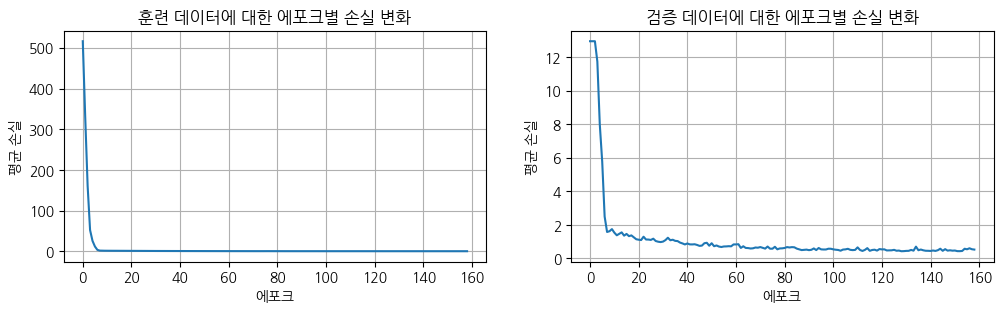

In [ ]:
np.random.seed(42)  # 결과 재현성을 위한 랜덤시드 고정
# 하이퍼 파라미터 설정
epochs = 300
batch_size = 32
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
n_features = x_train.shape[1] # 입력 변수의 수(5)

@tf.function  # GPU에서 그래프 모드로 빠른 실행
def train_step(x_batch, y_batch): # 벡터 변환과 손실 계산, 경사하강법을 함수로 정의
    with tf.GradientTape() as tape:
        x1 = tf.nn.relu(tf.matmul(x_batch, w1) + b1) # 은닉층 1: 선형변환 후, Relu 활성화 함수 적용
        x2 = tf.nn.relu(tf.matmul(x1, w2) + b2)      # 은닉층 2
        y_pred = tf.nn.softmax(tf.matmul(x2, w3) + b3)      # 은닉층 3 (소프트맥스 변환)
        loss = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_batch, y_pred))    # categorica CE 손실
    grads = tape.gradient(loss, [w1, b1, w2, b2, w3, b3]) # 텐서 자동 미분
    optimizer.apply_gradients(zip(grads, [w1, b1, w2, b2, w3, b3])) # 경사하강법으로 파라미터 업데이트
    return loss

x_data_train = tf.cast(x_train, tf.float32) # 입력과 타깃 데이터를 텐서로 변환
y_data_train = tf.cast(y_train, tf.float32)
x_data_test = tf.cast(x_test, tf.float32)
y_data_test = tf.cast(y_test, tf.float32)

# 학습용 데이터셋 구성
train_dataset = tf.data.Dataset.from_tensor_slices((x_data_train, y_data_train))
train_dataset = train_dataset.shuffle(buffer_size=len(x_data_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# --- Early Stopping 설정 변수 ---
patience = 30         # 성능 개선이 없어도 참아줄 횟수
wait = 0              # 현재 참고 있는 횟수
best_val_loss = float('inf')  # 역대 최저 검증 손실 기록용
# ------------------------------

# 파라미터 초기화
initializer = tf.keras.initializers.GlorotNormal() # 가중치 행렬 초기화 도구
w1 = tf.Variable(initializer([ n_features, 16]))  # 차원을 정확하게 지정해야 함
w2 = tf.Variable(initializer([16,  8]))
w3 = tf.Variable(initializer([ 8,  num_class]))
b1 = tf.Variable(tf.zeros([16])) # 편향은 0에서 시작
b2 = tf.Variable(tf.zeros([ 8]))
b3 = tf.Variable(tf.zeros([ num_class]))

# 메인 학습 루프
loss_history=[]; val_loss_history = []
for epoch in range(epochs):
    epoch_loss = 0.0
    for x_batch, y_batch in train_dataset:
        loss = train_step(x_batch, y_batch)
        epoch_loss += loss
    epoch_loss /= tf.cast(len(x_data_train)/batch_size, tf.float32) # 에포크별 평균 손실

    # [검증 단계] - 학습하지 않고 손실만 계산
    y_pred_test = tf.nn.softmax(tf.matmul(tf.nn.relu(tf.matmul(tf.nn.relu(tf.matmul(x_data_test, w1) + b1), w2) + b2), w3) + b3)
    epoch_val_loss = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_data_test, y_pred_test))

    loss_history.append(epoch_loss)
    val_loss_history.append(epoch_val_loss)
    print(f"Epoch {epoch+1}: Train_loss {epoch_loss:.4f}, Test_loss {epoch_val_loss:.4f}")

    # --- Early Stopping 로직 실행 ---
    if epoch_val_loss < best_val_loss:
          best_val_loss = epoch_val_loss
          wait = 0  # 새로운 최저점을 찾았으므로 인내심 초기화
    else:
        wait += 1  # 개선이 없으면 인내심 1 깎기
        if wait >= patience:
            print(f"★ {epoch+1} 에포크에서 조기 종료! (Val_Loss 개선 없음)")
            break


# 학습 과정 시각화
plt.figure(figsize=(12, 3))
plt.subplot(1,2,1)
plt.plot(loss_history)
plt.title("훈련 데이터에 대한 에포크별 손실 변화")
plt.xlabel("에포크"); plt.ylabel("평균 손실")
plt.grid(True);
plt.subplot(1,2,2)
plt.plot(val_loss_history)
plt.title("검증 데이터에 대한 에포크별 손실 변화")
plt.xlabel("에포크"); plt.ylabel("평균 손실")
plt.grid(True); plt.show()

사용자 친화적인 케라스의 레이어 인터페이스를 사용하는 것이 편리하고 속도도 더 빠르긴 하지만, 이처럼 로우레벨 코드로 직접 텐서를 다루어보면 딥러닝 모델에 대한 여러분의 이해도를 더욱 높일 수 있습니다.

---



## **[참고] 인공 신경망 분류 모델에서 역전파 과정의 이해**

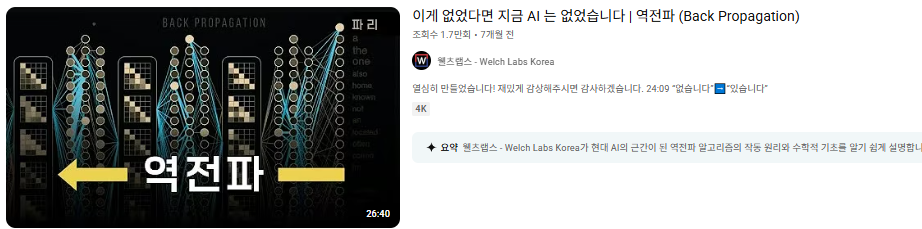

### https://www.youtube.com/watch?v=kFDvDPj6D4U

딥러닝 학습의 핵심인 **역전파** 과정을 매우 정확하게 시각적으로 설명하고 있는 영상입니다.

- 앞의 2분 30초만 봐도 좋고, 좀 길지만 끝까지 시청하면 큰 도움이 됩니다.  